In [18]:
import numpy as np
import matplotlib.pyplot as plt
import json
import pickle
import pandas as pd

import sys

sys.path.append("..")

from src.conformal_prediction.utils import compute_coverage, compute_volume_ellipsoid

In [19]:
def set_style():
    plt.rcParams["text.usetex"] = True
    font = {"family": "normal", "weight": "bold", "size": 20}
    plt.rc("font", **font)

In [20]:
set_style()

In [21]:
def reader(path_params):
    with open(path_params, "r") as file:
        params = json.load(file)
    print(params)
    return params


def load_list_with_pickle(file_name):
    with open(file_name, "rb") as file:
        result = pickle.load(file)
    return result


def save_list_with_pickle(my_list, file_name):
    with open(file_name, "wb") as file:
        pickle.dump(my_list, file)

# Conformal prediction regions with fixed output covariance

In [22]:
index = 1
params_path = "params/n{}.json".format(index)
input_path = "results/prediction_regions/n{}/fixed/".format(index)

In [23]:
result = load_list_with_pickle(input_path + "result.pkl")

In [24]:
rep_number = len(result["upper_prediction_regions"])
columns = ["coverage", "length", "time"]
conformal_predictors_names = ["OracleCP", "SplitCP", "StableCP"]
df_result = {}
for key in conformal_predictors_names:
    df_result[key] = pd.DataFrame(np.zeros((rep_number, len(columns))), columns=columns)

In [25]:
def record(new_output, prediction_region, time):
    return np.array(
        [
            np.float64(compute_coverage(prediction_region, new_output)),
            compute_volume_ellipsoid(
                prediction_region[-1], prediction_region[1]
            ).item(),
            time
        ],
        dtype=object,
    )

In [26]:
for iter in range(rep_number):
    df_result["OracleCP"].iloc[iter] = record(
        result["new_outputs"][iter], result["oracle_prediction_regions"][iter], result["oracle_prediction_run_times"][iter]/result["oracle_prediction_run_times"][iter]
    )
    df_result["SplitCP"].iloc[iter] = record(
        result["new_outputs"][iter], result["split_prediction_regions"][iter], result["split_prediction_run_times"][iter]/result["oracle_prediction_run_times"][iter]
    )
    df_result["StableCP"].iloc[iter] = record(
        result["new_outputs"][iter], result["upper_prediction_regions"][iter], result["upper_prediction_run_times"][iter]/result["oracle_prediction_run_times"][iter]
    )

In [27]:
def plot(df_result, colors):
    def labelize(name, df):

        cov = r"$\overline{cov}$ = "
        run_time = r"$\overline{T}$ = "
        mean_cov = str(np.round(df["coverage"].mean(), 2))
        mean_time = str(np.round(df["time"].mean(), 2))
        return name + " \n" + cov + mean_cov + " \n" + run_time + mean_time

    labels = []
    df_length = []
    for key in df_result.keys():
        labels += [labelize(key, df_result[key])]
        df_length += [df_result[key]["length"]]

    fig, ax = plt.subplots(figsize=(13, 5))
    box = ax.boxplot(df_length, patch_artist=True)
    ax.set_ylabel("Volume")

    for patch, color in zip(box["boxes"], colors):
        patch.set_facecolor(color)

    ax.grid(False)
    ax.set_xticks(np.arange(1, len(labels) + 1), labels)
    fig.tight_layout()
    ax.set_title("Comparison of volumes of prediction regions")

    return fig

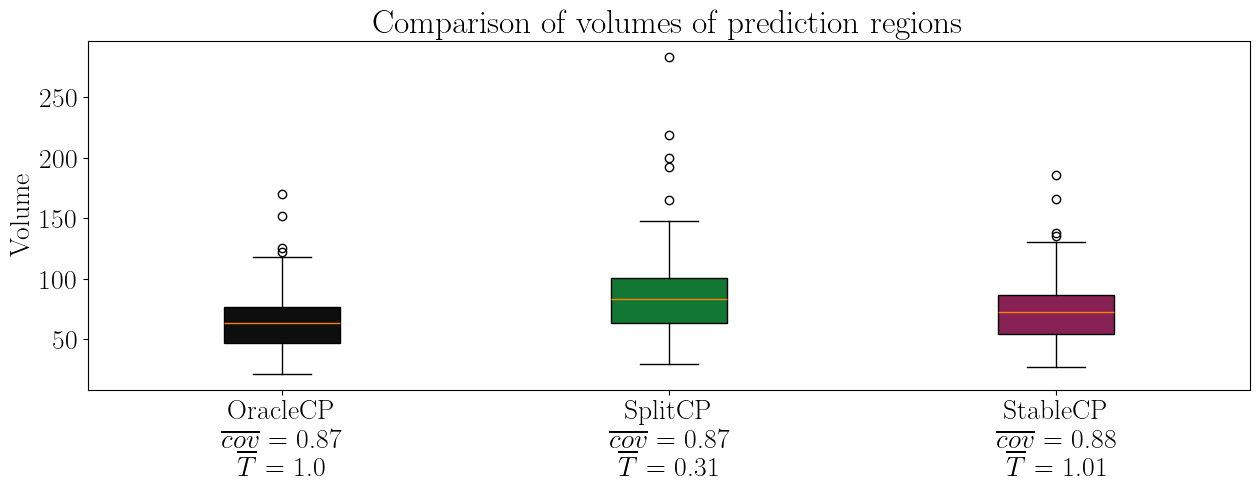

In [28]:
CP_colors = ["#0E0E0E", "#117733", "#882255"]
set_style()
fig = plot(df_result, CP_colors)

In [29]:
fig.savefig(
    input_path + "prediction_region_volumes_fixed" + ".eps", format="eps", bbox_inches="tight"
)

Failed to find a Ghostscript installation.  Distillation step skipped.


In [30]:
fig.savefig(
    input_path + "prediction_region_volumes_fixed" + ".jpeg",
    format="jpeg",
    bbox_inches="tight",
)

In [31]:
def plot_ratio(df_result, colors, shift):
    def labelize(name, df):

        cov = r"$\overline{cov}$ = "
        run_time = r"$\overline{T}$ = "
        mean_cov = str(np.round(df["coverage"].mean(), 2))
        mean_time = str(np.round(df["time"].mean(), 2))
        return name + " \n" + cov + mean_cov + " \n" + run_time + mean_time

    labels = []
    df_length = []
    for key in df_result.keys():
        if key != "OracleCP":
            labels += [labelize(key, df_result[key])]
            df_length += [df_result[key]["length"] / df_result["OracleCP"]["length"]]

    fig, ax = plt.subplots(figsize=(13, 5))
    box = ax.boxplot(df_length, patch_artist=True)
    ax.set_ylabel(r"Volume relative to \textbf{OracleCP}'s")

    for patch, color in zip(box["boxes"], colors):
        patch.set_facecolor(color)

    ax.plot(
        [1-shift, 2+shift], [1, 1], color="red"
    )

    ax.grid(False)
    ax.set_xticks(np.arange(1, len(labels) + 1), labels)
    fig.tight_layout()
    # ax.set_title(r"Comparison of relative volumes of \textbf{OracleCP} of prediction regions")

    return fig

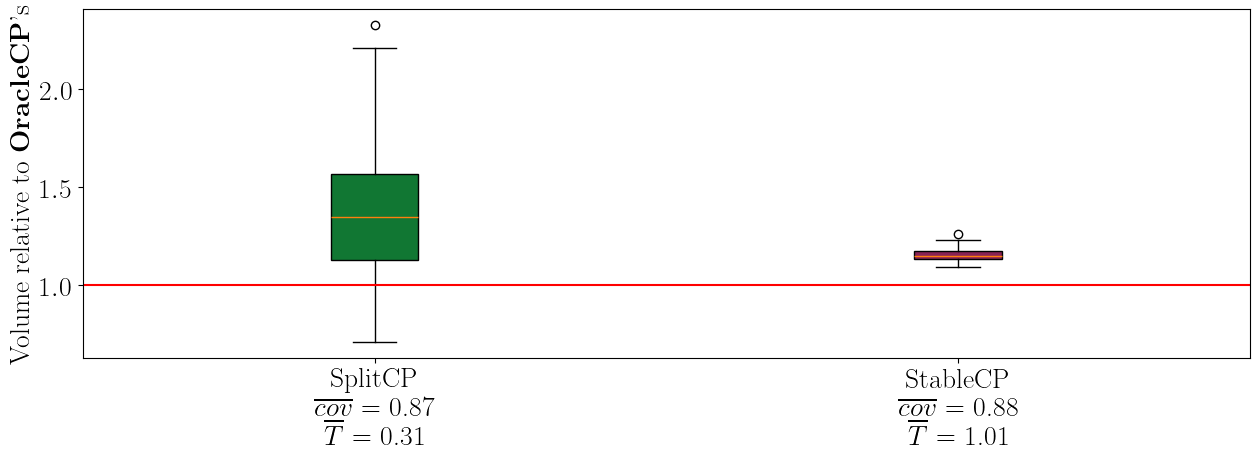

In [32]:
CP_colors = [
    #"#0E0E0E",
    "#117733", "#882255"]
set_style()
fig = plot_ratio(df_result, CP_colors, 0.5)

In [33]:
fig.savefig(
    input_path + "prediction_region_relative_volumes_fixed" + ".eps",
    format="eps",
    bbox_inches="tight",
)

Failed to find a Ghostscript installation.  Distillation step skipped.


In [34]:
fig.savefig(
    input_path + "prediction_region_relative_volumes_fixed" + ".jpeg",
    format="jpeg",
    bbox_inches="tight",
)